# TASK 1 – EDA on Retail Sales Data

## Objective

Perform Exploratory Data Analysis (EDA) on a retail sales dataset to understand data structure, sales trends, customer segments, product performance, and relationships between key numerical variables.

## Tech Stack

- Python
- pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Project Overview

In this project, we will load and inspect the retail sales dataset, perform descriptive statistical analysis, analyse sales trends over time, study customer and product performance, examine correlations between numerical variables, create meaningful visualizations, and derive data-driven business insights and recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Sample-Superstore-Orders.xlsx", sheet_name="Orders")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2021-103800,2021-01-03,2021-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2021-141817,2021-01-05,2021-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Number of rows: 10194
Number of columns: 21

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 

In [4]:
numeric_columns = ["Sales", "Quantity", "Discount", "Profit"]

statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

statistics

,Mean,Median,Mode,Standard Deviation
Sales,228.225854,53.91,12.96,619.906839
Quantity,3.791838,3.00,2.00,2.228317
Discount,0.155385,0.20,0.00,0.206249
Profit,28.673417,8.69,0.00,232.465115


In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
print("Order Date data type:", df["Order Date"].dtype)

Order Date data type: datetime64[ns]


In [6]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)
monthly_sales

Order Date
2021-01     14518.0550
2021-02      4519.8920
2021-03     56933.9090
2021-04     28295.3450
2021-05     26319.7670
2021-06     34669.4796
2021-07     33946.3930
2021-08     28918.3385
2021-09     82670.4288
2021-10     32413.3390
2021-11     78826.9567
2021-12     72008.3085
2022-01     18461.9156
2022-02     11951.4110
2022-03     39978.6280
2022-04     34195.2085
2022-05     30246.9465
2022-06     24797.2920
2022-07     28765.3250
2022-08     37057.0042
2022-09     64627.0460
2022-10     31407.1335
2022-11     75972.5635
2022-12     75532.5572
2023-01     18830.3310
2023-02     22978.8150
2023-03     53031.0690
2023-04     38829.1590
2023-05     57042.8380
2023-06     40937.1480
2023-07     40300.4990
2023-08     31716.8143
2023-09     73521.6629
2023-10     59831.0010
2023-11     79411.9658
2023-12     97502.2770
2024-01     44259.2140
2024-02     20301.1334
2024-03     60728.4808
2024-04     36779.0361
2024-05     45155.4822
2024-06     53056.0777
2024-07     45989.4960


In [7]:
quarterly_sales = (
    df.groupby(df["Order Date"].dt.to_period("Q"))["Sales"]
    .sum()
)
quarterly_sales

Order Date
2021Q1     75971.8560
2021Q2     89284.5916
2021Q3    145535.1603
2021Q4    183248.6042
2022Q1     70391.9546
2022Q2     89239.4470
2022Q3    130449.3752
2022Q4    182912.2542
2023Q1     94840.2150
2023Q2    136809.1450
2023Q3    145538.9762
2023Q4    236745.2438
2024Q1    125288.8282
2024Q2    134990.5960
2024Q3    198183.7860
2024Q4    287104.3210
Freq: Q-DEC, Name: Sales, dtype: float64

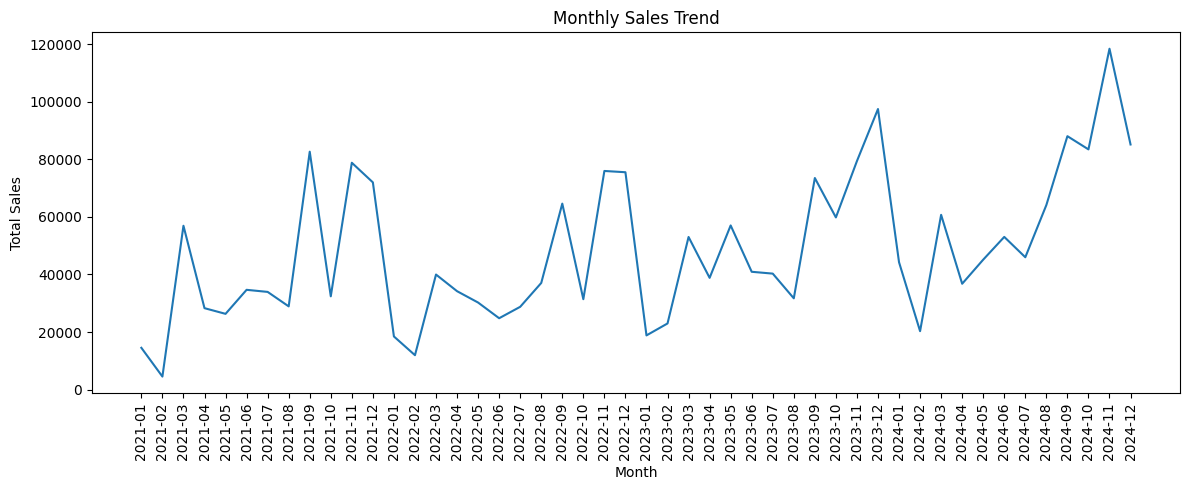

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation – Monthly Sales Trend

The monthly sales trend shows substantial variation across the period from January 2021 to December 2024. Sales reach several high points during the later months of the year, with the highest monthly sales recorded in **November 2024 at approximately 118,454.51**. The lowest monthly sales were recorded in **February 2021 at approximately 4,519.89**. The pattern indicates noticeable month-to-month fluctuations in retail sales performance.


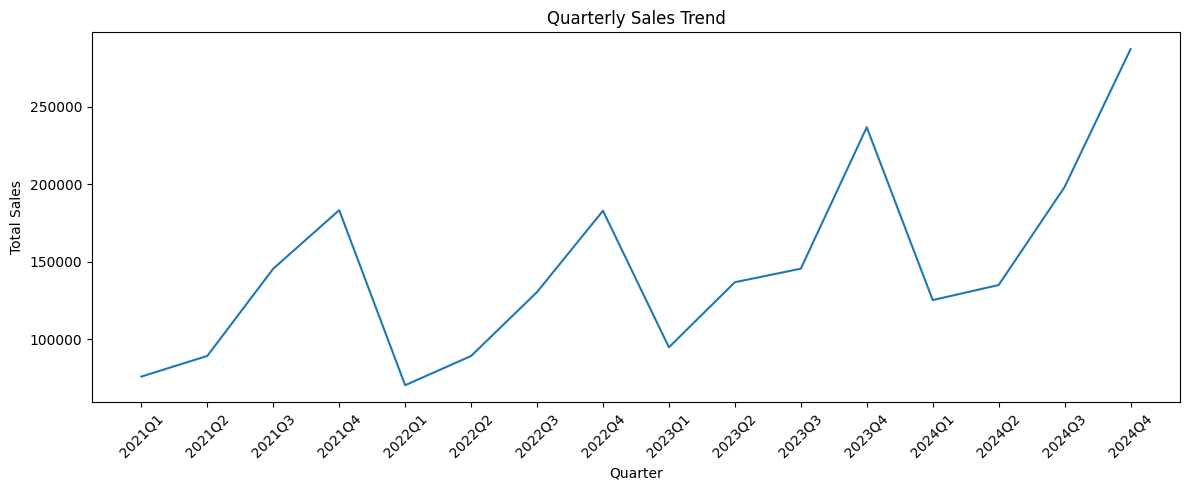

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(quarterly_sales.index.astype(str), quarterly_sales.values)
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation – Quarterly Sales Trend

Quarterly sales show noticeable variation across the 2021–2024 period. Sales generally increase toward the later quarters of the year, with **Q4 showing particularly strong performance**. The highest quarterly sales were recorded in **2024 Q4 at approximately 287,104**, while the lowest were recorded in **2022 Q1 at approximately 70,392**. This indicates stronger sales activity during the later part of the year.

### Customer Demographic Data Limitation

The Superstore Orders dataset does not contain customer age or gender information. Therefore, an age-group or gender-based demographic analysis cannot be performed directly from this dataset.

As an alternative, customer groups are analysed using the available **Segment** field (Consumer, Corporate, and Home Office).

In [10]:
segment_counts = df["Segment"].value_counts()
segment_counts

Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64

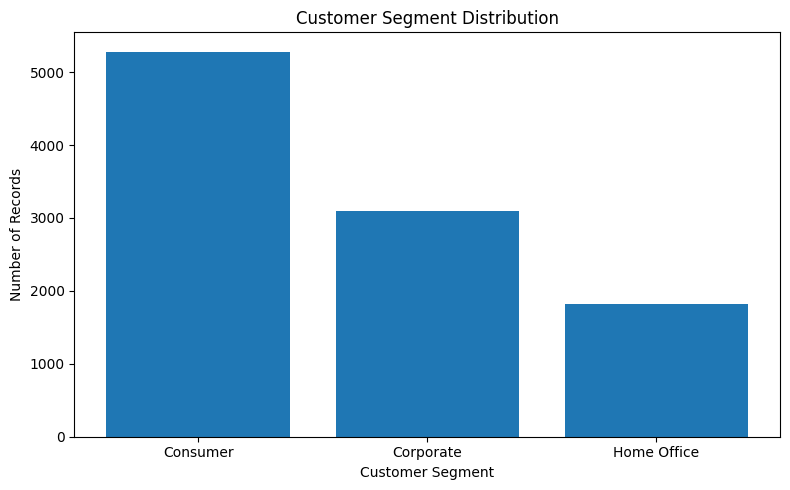

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(segment_counts.index, segment_counts.values)
plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Observation – Customer Segment Distribution

The **Consumer** segment has the largest number of records with **5,281**, followed by **Corporate** with **3,090** and **Home Office** with **1,823**. This shows that the Consumer segment represents the largest customer group in the dataset.

In [12]:
# Sales by Product Category
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

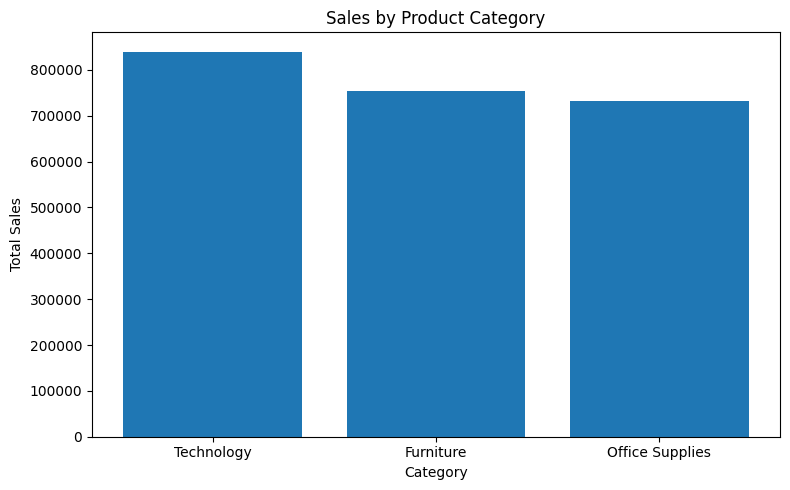

In [13]:
# Category-wise Sales
plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

### Observation – Category-wise Sales

Technology recorded the highest total sales at approximately **839,893.28**, followed by Furniture at **754,747.76** and Office Supplies at **731,893.31**. Technology therefore generated the highest sales among the three product categories in the dataset.

In [14]:
# Top 10 Best-Selling Products
top_10_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_10_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

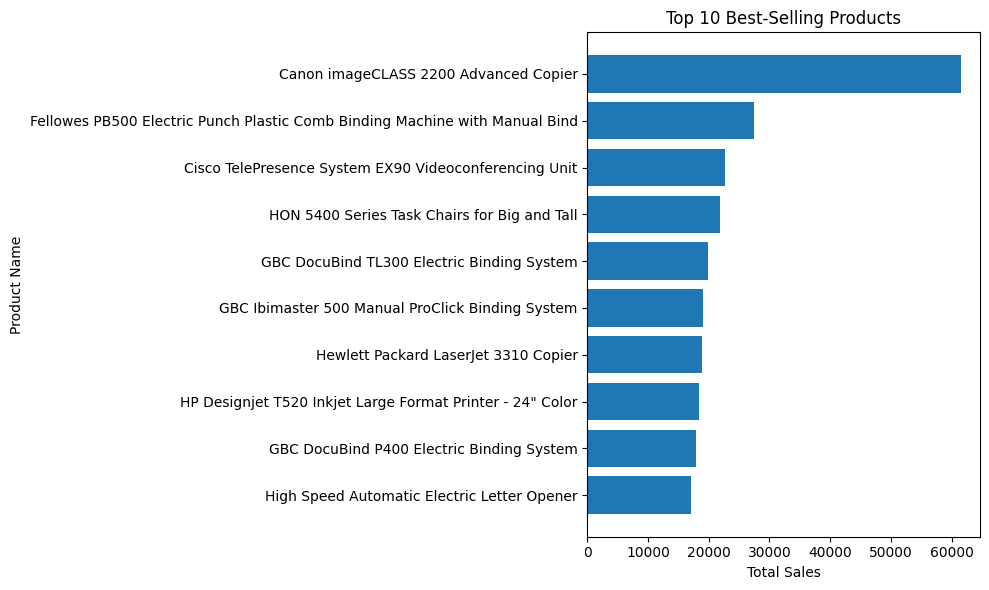

In [15]:
# Top 10 Best-Selling Products
plt.figure(figsize=(10, 6))
plt.barh(top_10_products.index[::-1], top_10_products.values[::-1])
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

### Observation – Top 10 Best-Selling Products

The **Canon imageCLASS 2200 Advanced Copier** generated the highest total sales among the products analyzed, with approximately **61,599.82** in sales. The remaining top-selling products are primarily copiers, printers, binding systems, and other office equipment. This indicates that high-value office technology and equipment products contribute significantly to total sales in the dataset.


In [16]:
numeric_columns = ["Sales", "Quantity", "Discount", "Profit"]
correlation_matrix = df[numeric_columns].corr()
correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.198457,-0.027756,0.481460
Quantity,0.198457,1.000000,0.007475,0.066145
Discount,-0.027756,0.007475,1.000000,-0.218882
Profit,0.481460,0.066145,-0.218882,1.000000


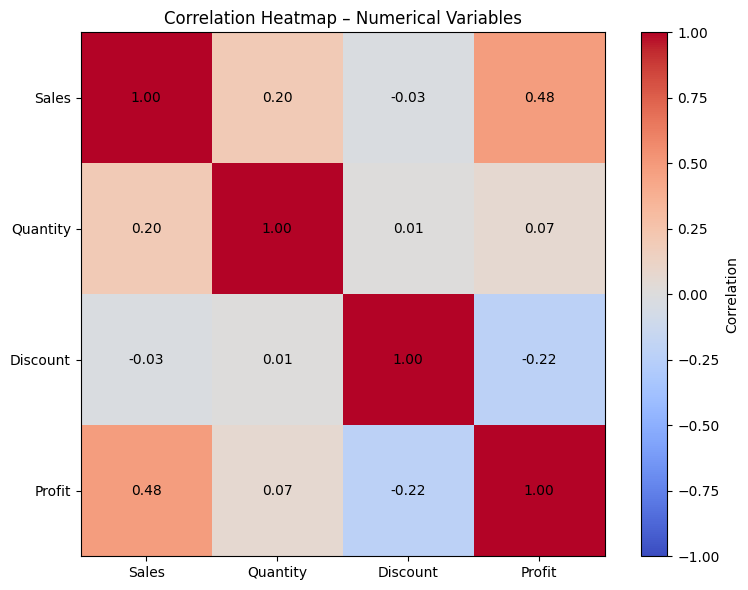

In [17]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )
plt.title("Correlation Heatmap – Numerical Variables")
plt.tight_layout()
plt.show()

### Observation – Correlation Heatmap

The correlation analysis shows a moderate positive relationship between **Sales and Profit (0.48)**, indicating that higher sales are generally associated with higher profit, although the relationship is not strong enough to explain profit by sales alone.

**Discount and Profit have a weak negative correlation (-0.22)**, suggesting that higher discount levels are associated with lower profit in this dataset.

The relationships between Quantity and Profit (0.07), Sales and Discount (-0.03), and Quantity and Discount (0.01) are weak or nearly zero, indicating little linear relationship between these variables.

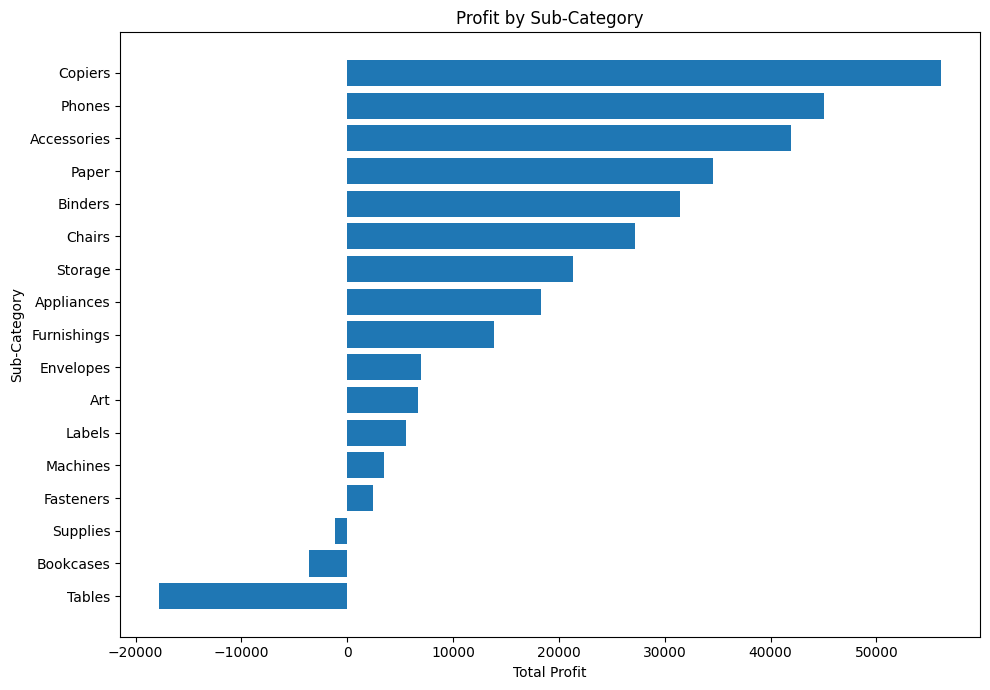

In [18]:
# Profit by Sub-Category

subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)
plt.figure(figsize=(10, 7))
plt.barh(subcategory_profit.index, subcategory_profit.values)
plt.title("Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

### Observation – Profit by Sub-Category

The profit analysis reveals significant differences across sub-categories. **Copiers** generate the highest total profit, followed by **Phones** and **Accessories**.

A notable finding is that **Tables and Bookcases generate negative total profit**, while Supplies also show a small negative profit. This indicates that some sub-categories may generate sales but still reduce overall profitability. Therefore, sales performance should be evaluated together with profit when making product and pricing decisions.


## Business Recommendations

Based on the EDA findings, the following actions are recommended:

1. **Prioritise high-profit technology products:** Technology recorded the highest category sales, while Copiers generated the highest total profit. The business should maintain strong inventory availability and targeted promotions for high-performing technology products.

2. **Review pricing and profitability of loss-making sub-categories:** Tables and Bookcases generated negative total profit. These sub-categories should be reviewed for pricing, discounting, product costs, and other factors affecting margins before increasing their sales volume.

3. **Prepare inventory and marketing plans for Q4:** Quarterly analysis shows particularly strong sales during the later part of the year, with 2024 Q4 recording the highest quarterly sales. Inventory, staffing, and promotional planning should be strengthened ahead of Q4.

4. **Focus customer engagement on the Consumer segment:** Consumer represents the largest segment in the dataset. Targeted campaigns and product offers can be designed for this segment while continuing to develop Corporate and Home Office opportunities.

5. **Monitor discounting alongside profitability:** The correlation between Discount and Profit is weakly negative (-0.22). Discount strategies should therefore be monitored together with profit margins rather than focusing only on sales volume.

# Conclusion

The Exploratory Data Analysis of the Superstore retail sales dataset identified important patterns in sales, customer segments, product performance, profitability, and numerical relationships.

The analysis showed strong variation in monthly and quarterly sales, with particularly strong performance toward the end of the year. Technology recorded the highest category sales, while the Consumer segment represented the largest customer segment by order records. The product and sub-category analysis showed that Copiers were a major contributor to profit, while Tables and Bookcases generated negative total profit.

The correlation analysis showed a moderate positive relationship between Sales and Profit and a weak negative relationship between Discount and Profit.

Overall, the EDA provides data-driven insights that can support inventory planning, product strategy, pricing decisions, customer targeting, and seasonal business planning.